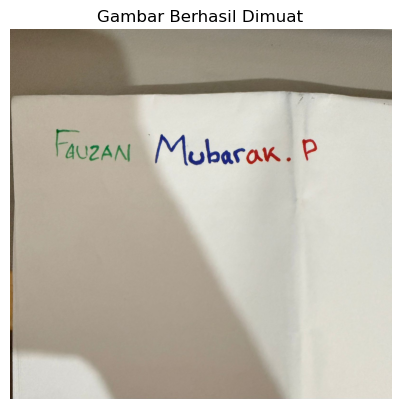

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load citra (Pastikan nama file dan ekstensinya sudah benar)
# Jika nama file kamu di folder adalah 'nama.png', ganti .jpg menjadi .png
img = cv2.imread('nama.jpeg') 

if img is None:
    print("Error: File tidak ditemukan. Pastikan nama file 'nama.jpg' sama persis dengan yang ada di folder!")
else:
    # Konversi Warna
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Tampilkan Gambar Asli untuk memastikan berhasil dimuat
    plt.imshow(img_rgb)
    plt.title('Gambar Berhasil Dimuat')
    plt.axis('off')
    plt.show()

In [5]:
# 2. Definisi batas bawah (lower) dan batas atas (upper) warna dalam HSV
# Merah (memiliki dua rentang karena berada di ujung spektrum)
lower_red1 = np.array([0, 50, 50]); upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 50, 50]); upper_red2 = np.array([180, 255, 255])

# Hijau
lower_green = np.array([35, 90, 50]); upper_green = np.array([90, 255, 255])

# Biru
lower_blue = np.array([90, 50, 50]); upper_blue = np.array([130, 255, 255])

# Membuat Masking (Filter)
mask_r = cv2.addWeighted(cv2.inRange(img_hsv, lower_red1, upper_red1), 1.0, 
                         cv2.inRange(img_hsv, lower_red2, upper_red2), 1.0, 0)
mask_g = cv2.inRange(img_hsv, lower_green, upper_green)
mask_b = cv2.inRange(img_hsv, lower_blue, upper_blue)

# Menerapkan Masking ke gambar asli
res_red = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_r)
res_green = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_g)
res_blue = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_b)

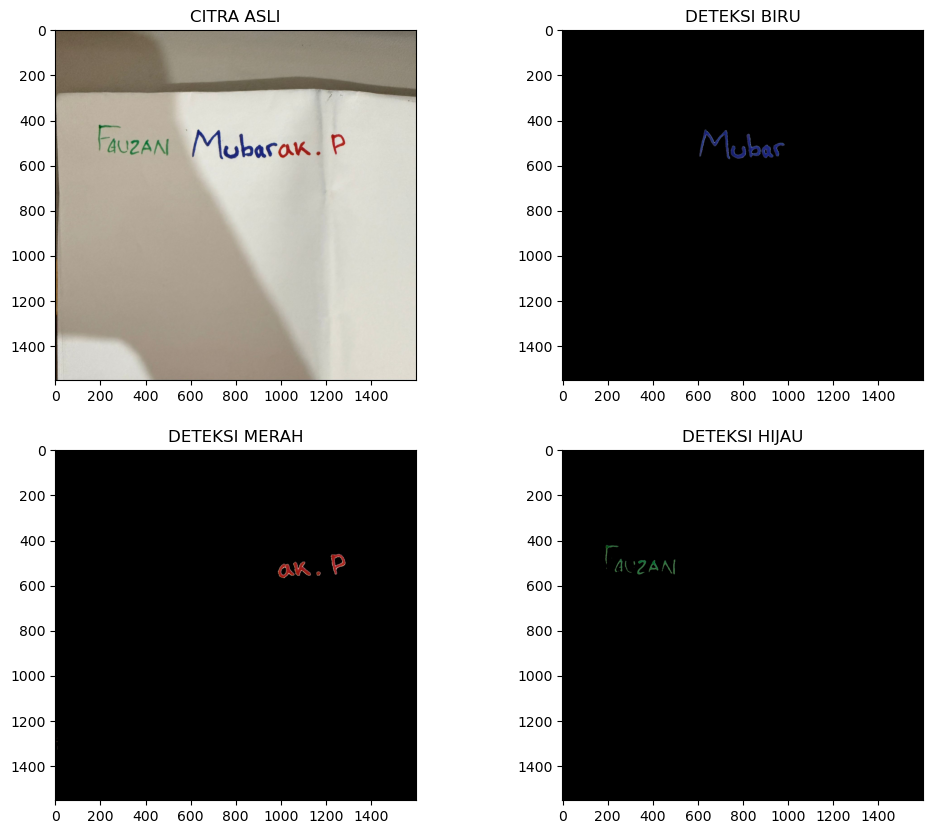

In [6]:
# 3. Menampilkan hasil deteksi
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(img_rgb); axs[0, 0].set_title('CITRA ASLI')
axs[0, 1].imshow(res_blue); axs[0, 1].set_title('DETEKSI BIRU')
axs[1, 0].imshow(res_red); axs[1, 0].set_title('DETEKSI MERAH')
axs[1, 1].imshow(res_green); axs[1, 1].set_title('DETEKSI HIJAU')

for ax in axs.flat:
    ax.axis('on') # Tetap tampilkan koordinat seperti contoh soal
plt.show()

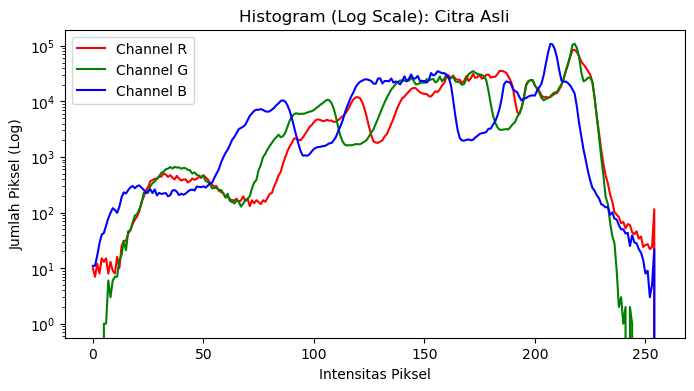

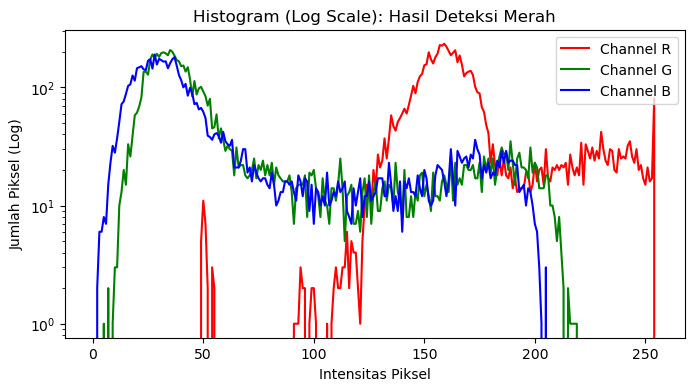

In [10]:
# 4. Fungsi untuk membuat histogram Logaritmik
def plot_log_hist(img_res, title):
    colors = ('r', 'g', 'b')
    plt.figure(figsize=(8, 4))
    for i, col in enumerate(colors):
        # Hitung histogram, mulai dari intensitas 1 agar log(0) tidak error
        hist = cv2.calcHist([img_res], [i], None, [256], [1, 256])
        plt.plot(hist, color=col, label=f'Channel {col.upper()}')
    
    plt.yscale('log') # CRITICAL: Mengaktifkan Skala Logaritmik
    plt.title(f'Histogram (Log Scale): {title}')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel (Log)')
    plt.legend()
    plt.show()

# Jalankan untuk citra asli dan hasil deteksi
plot_log_hist(img_rgb, "Citra Asli")
plot_log_hist(res_red, "Hasil Deteksi Merah")


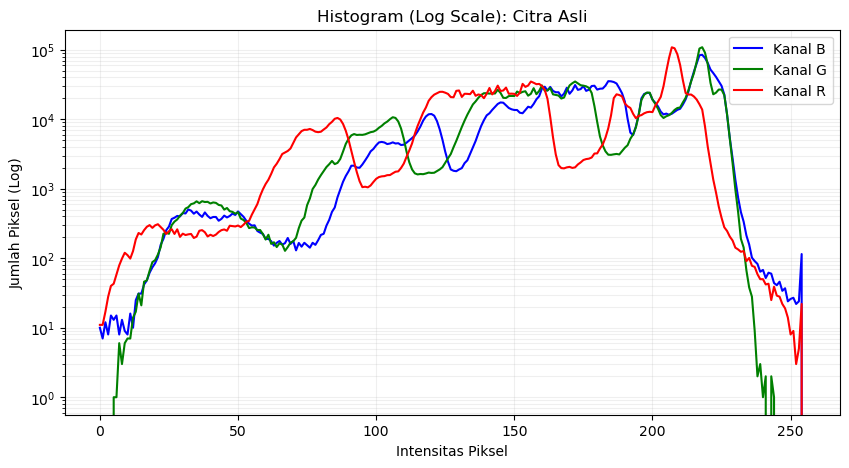

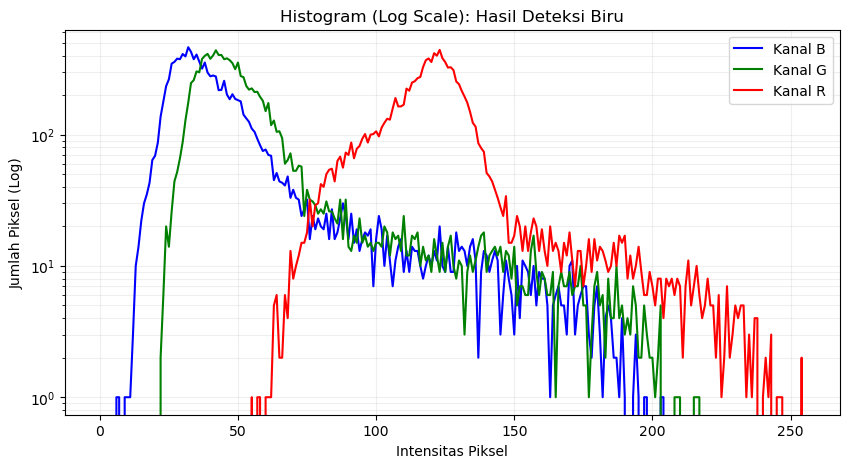

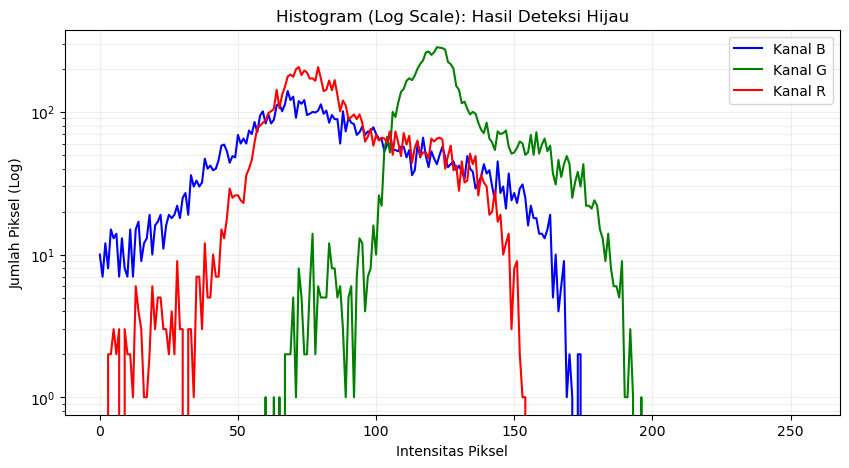

In [11]:
# Fungsi untuk menampilkan histogram dengan Skala Logaritmik
def tampilkan_histogram(gambar, judul):
    plt.figure(figsize=(10, 5))
    warna = ('b', 'g', 'r') # OpenCV menggunakan urutan BGR
    
    for i, col in enumerate(warna):
        # Menghitung histogram untuk setiap kanal warna
        # Range [1, 256] digunakan agar nilai 0 (background hitam) tidak mendominasi grafik
        hist = cv2.calcHist([gambar], [i], None, [256], [1, 256])
        
        plt.plot(hist, color=col, label=f'Kanal {col.upper()}')
        plt.yscale('log') # Mengaktifkan skala logaritmik sesuai standar laporan [cite: 338]

    plt.title(f'Histogram (Log Scale): {judul}')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel (Log)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# 1. Tampilkan Histogram Citra Asli
tampilkan_histogram(img_rgb, "Citra Asli")

# 2. Tampilkan Histogram Hasil Deteksi Biru
tampilkan_histogram(res_biru, "Hasil Deteksi Biru")

# 3. Tampilkan Histogram Hasil Deteksi Hijau
tampilkan_histogram(res_hijau, "Hasil Deteksi Hijau")

In [13]:
# 1. Load foto backlight
img_back = cv2.imread('foto.jpeg')

if img_back is None:
    print("Error: File foto.jpg tidak ditemukan!")
else:
    # Konversi ke RGB untuk tampilan Matplotlib
    img_back_rgb = cv2.cvtColor(img_back, cv2.COLOR_BGR2RGB)
    
    # c) Konversi ke Grayscale (Wajib sesuai soal)
    img_gray = cv2.cvtColor(img_back, cv2.COLOR_BGR2GRAY)
    
    print("Foto berhasil dimuat dan dikonversi ke grayscale.")

Foto berhasil dimuat dan dikonversi ke grayscale.


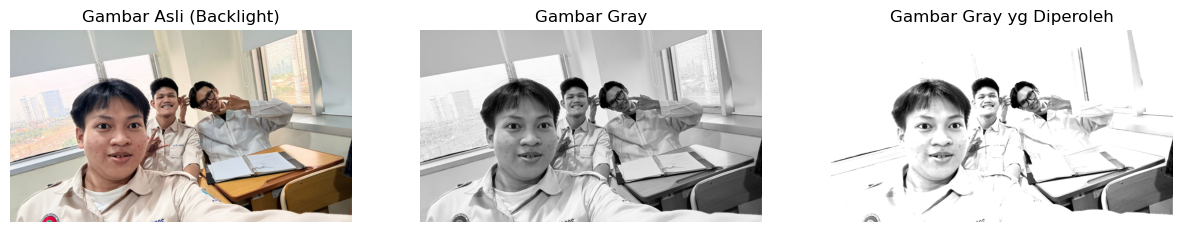

In [16]:
# d) Pengaturan Kecerahan dan Kontras
# Silakan ubah nilai alpha dan beta sampai wajahmu terlihat jelas tapi tidak 'terbakar'
alpha = 1.3  # Kontras
beta = 60    # Kecerahan

# Implementasi operasi pixel
img_terang = cv2.convertScaleAbs(img_gray, alpha=alpha, beta=beta)

# Menampilkan hasil sesuai urutan di dokumen tugas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_back_rgb)
plt.title('Gambar Asli (Backlight)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Gambar Gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_terang, cmap='gray')
plt.title('Gambar Gray yg Diperoleh')
plt.axis('off')

plt.show()

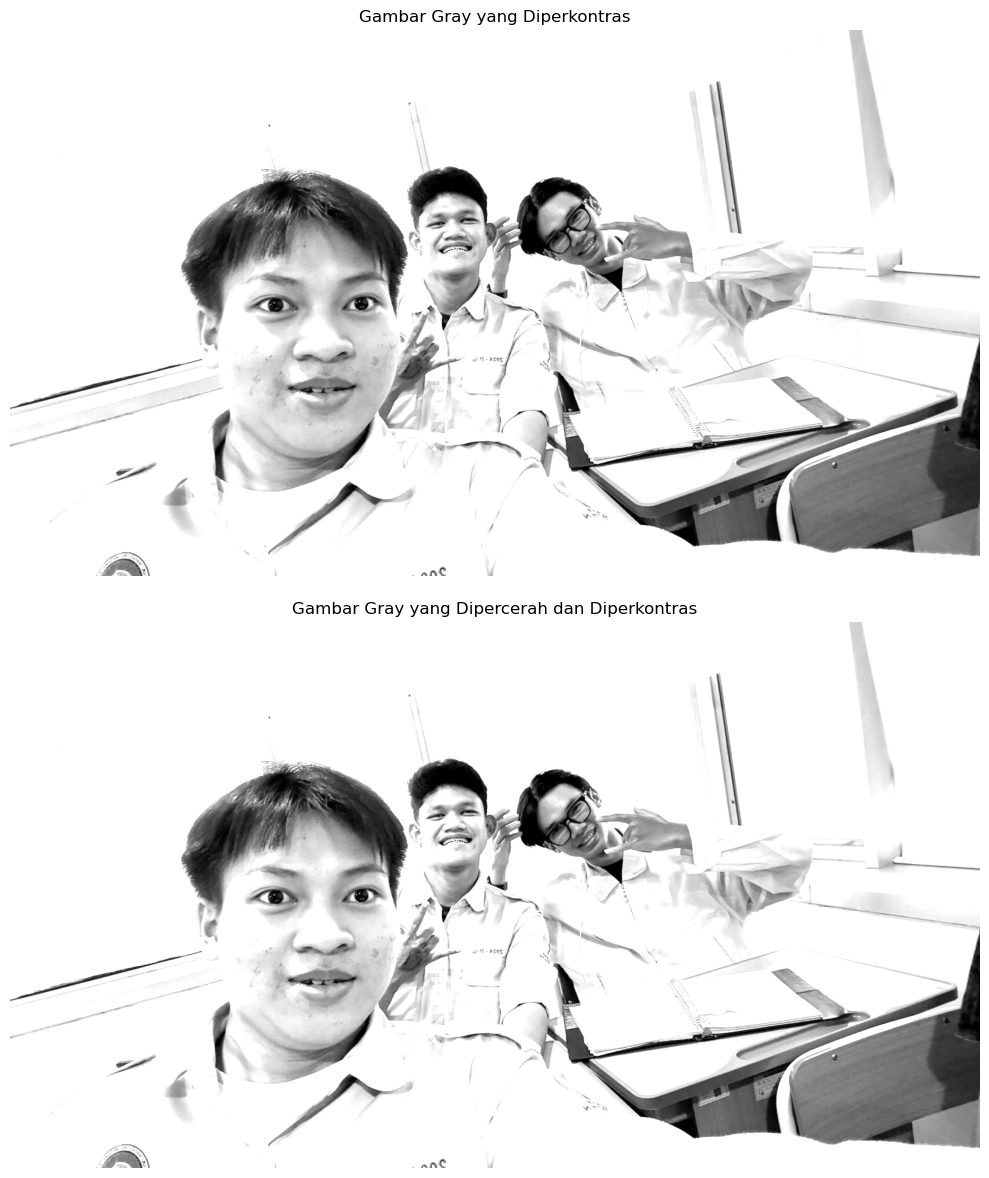

In [15]:
# 1. Pastikan foto sudah dimuat di sel sebelumnya
# Kita akan membuat dua variasi hasil sesuai gambar yang kamu unggah

# Variasi A: Gambar Gray yang Diperkontras (Hanya menaikkan Alpha)
alpha_only = 1.6 
beta_none = 0
img_diperkontras = cv2.convertScaleAbs(img_gray, alpha=alpha_only, beta=beta_none)

# Variasi B: Gambar Gray yang Dipercerah dan Diperkontras (Menaikkan Alpha & Beta)
alpha_final = 1.3
beta_final = 60
img_final = cv2.convertScaleAbs(img_gray, alpha=alpha_final, beta=beta_final)

# 2. Menampilkan hasil sesuai screenshot kamu
plt.figure(figsize=(10, 12))

plt.subplot(2, 1, 1)
plt.imshow(img_diperkontras, cmap='gray')
plt.title('Gambar Gray yang Diperkontras')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img_final, cmap='gray')
plt.title('Gambar Gray yang Dipercerah dan Diperkontras')
plt.axis('off')

plt.tight_layout()
plt.show()